# 《人工智能基础A》实验报告三
## 机器学习回归与sklearn使用

### sklearn基本用法

均方误差 (MSE): 0.2294383117428572
决定系数 (R^2): 0.8884238421839267


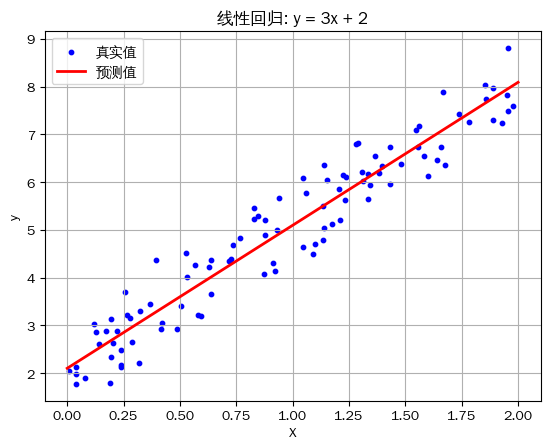

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 手动添加字体路径
font_manager.fontManager.addfont('/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc')

# 设置字体为WenQuanYi Zen Hei
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 设置随机种子以确保结果可重复
np.random.seed(0)

# 生成自变量x，并添加噪声生成因变量y
X = 2 * np.random.rand(100, 1)
y = 3 * X.flatten() + 2 + np.random.randn(100) * 0.5  # 模拟 y = 3x + 2，并加入随机噪声

# 分割数据集为训练集和测试集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建线性回归模型
model = LinearRegression()

# 使用训练集训练模型
model.fit(X_train, y_train)

# 对测试集进行预测
y_pred = model.predict(X_test)

# 计算性能指标
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 输出结果
print(f'均方误差 (MSE): {mse}')
print(f'决定系数 (R^2): {r2}')

# 绘制原始数据的散点图
plt.scatter(X, y, color='blue', label='真实值', s=10)

# 绘制回归线
X_line = np.linspace(0, 2, 100).reshape(-1, 1)
y_line = model.predict(X_line)

plt.plot(X_line, y_line, color='red', linewidth=2, label='预测值')

plt.xlabel('X')
plt.ylabel('y')
plt.title('线性回归: y = 3x + 2')
plt.legend()
plt.grid(True)
plt.show()

### 波士顿房价预测

>需要在较旧的版本的sklearn库下运行

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.datasets import load_boston
from matplotlib import font_manager


# 加载波士顿房价数据集
boston = load_boston()

# 将数据转换为DataFrame格式，方便处理
X_boston = pd.DataFrame(boston.data, columns=boston.feature_names)
y_boston = boston.target

# 打印数据概览
print("特征数据前5行：")
print(X_boston.head())
print("目标数据前5个值：")
print(y_boston[:5])

# 检查是否有缺失值
print("\n检查数据是否存在缺失值：")
print(X_boston.isnull().sum())  # 一般波士顿数据集没有缺失值

# 分割数据集，80%训练集，20%测试集
X_train, X_test, y_train, y_test = train_test_split(X_boston, y_boston, test_size=0.2, random_state=42)

# 创建线性回归模型
model = LinearRegression()

# 训练模型
model.fit(X_train, y_train)

# 进行预测
y_pred = model.predict(X_test)

# 计算性能指标
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 输出性能指标
print(f'\n波士顿房价预测 - 均方误差 (MSE): {mse}')
print(f'波士顿房价预测 - 决定系数 (R²): {r2}')

# 可视化结果：绘制真实值与预测值的散点图
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.xlabel('真实房价')
plt.ylabel('预测房价')
plt.title('波士顿房价预测 - 真实值 vs 预测值')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)  # 理想预测线
plt.grid(True)
plt.show()

### 加利福尼亚房价预测

特征数据前5行：
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
目标数据前5个值：
[4.526 3.585 3.521 3.413 3.422]

检查数据是否存在缺失值：
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

California房价预测 - 均方误差 (MSE): 0.5558915986952441
California房价预测 - 决定系数 (R²): 0.575787706032451


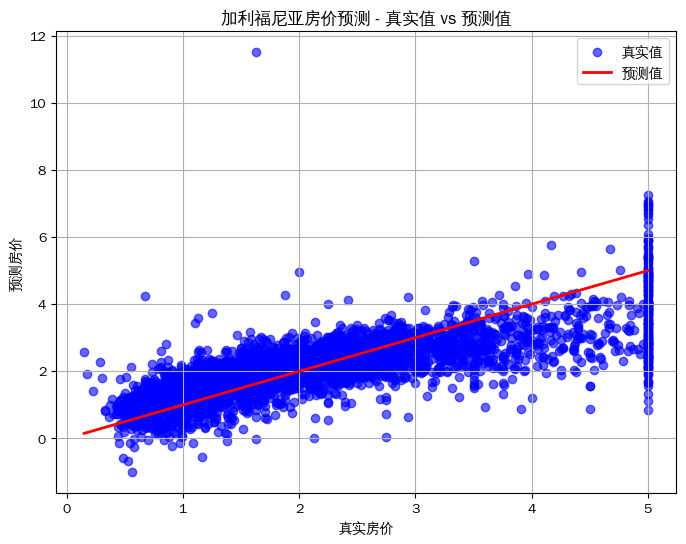

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from matplotlib import font_manager

# 手动添加字体路径，确保支持中文显示
font_manager.fontManager.addfont('/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc')
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 加载California房价数据集
housing = fetch_california_housing()

# 将数据转换为DataFrame格式，方便处理
X_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
y_housing = housing.target

# 打印数据概览
print("特征数据前5行：")
print(X_housing.head())
print("目标数据前5个值：")
print(y_housing[:5])

# 检查是否有缺失值
print("\n检查数据是否存在缺失值：")
print(X_housing.isnull().sum())  # 一般California housing数据集中没有缺失值

# 分割数据集，80%训练集，20%测试集
X_train, X_test, y_train, y_test = train_test_split(X_housing, y_housing, test_size=0.2, random_state=42)

# 创建线性回归模型
model = LinearRegression()

# 训练模型
model.fit(X_train, y_train)

# 进行预测
y_pred = model.predict(X_test)

# 计算性能指标
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 输出性能指标
print(f'\nCalifornia房价预测 - 均方误差 (MSE): {mse}')
print(f'California房价预测 - 决定系数 (R²): {r2}')

# 可视化结果：绘制真实值与预测值的散点图，并添加图例
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='真实值')  # 蓝色点表示真实值
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='预测值')  # 红色线表示预测值
plt.xlabel('真实房价')
plt.ylabel('预测房价')
plt.title('加利福尼亚房价预测 - 真实值 vs 预测值')
plt.legend()  # 添加图例
plt.grid(True)
plt.show()

### 乳腺癌检测

特征数据前5行：
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0  

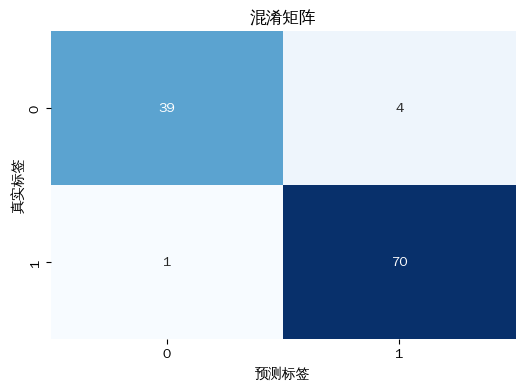

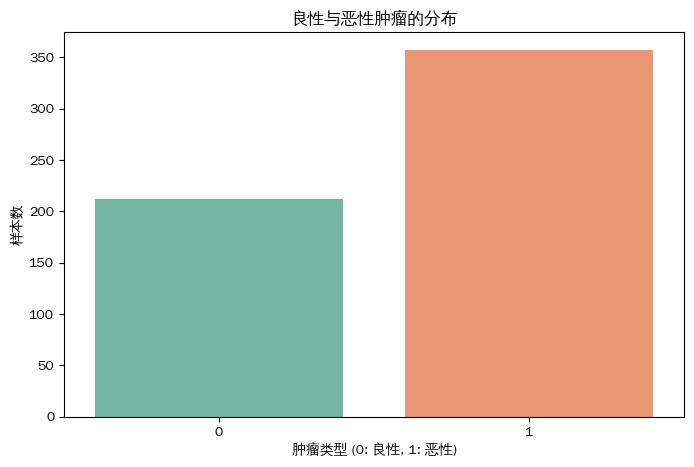

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from matplotlib import font_manager

font_manager.fontManager.addfont('/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc')
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 加载乳腺癌数据集
cancer = datasets.load_breast_cancer()

# 将特征数据转换为DataFrame，方便探索
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target  # 标签数据（0: 良性，1: 恶性）

# 查看数据集的前5行及对应标签
print("特征数据前5行：")
print(X.head())
print("目标标签前5个值：")
print(y[:5])

# 检查数据集的基本信息
print("\n数据集的基本信息：")
print(X.info())

# 检查是否有缺失值
print("\n检查数据是否存在缺失值：")
print(X.isnull().sum())

# 划分数据集，80%训练集，20%测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建逻辑回归模型，并设置最大迭代次数，确保收敛
model = LogisticRegression(max_iter=10000)

# 训练模型
model.fit(X_train, y_train)

# 对测试集进行预测
y_pred = model.predict(X_test)

# 计算模型的准确率
accuracy = accuracy_score(y_test, y_pred)

# 输出准确率
print(f"\n模型的准确率: {accuracy:.2f}")

# 计算并输出混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred)
print("\n混淆矩阵:")
print(conf_matrix)

# 可视化混淆矩阵
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("混淆矩阵")
plt.xlabel("预测标签")
plt.ylabel("真实标签")
plt.show()

# 可视化肿瘤类型的分布
plt.figure(figsize=(8, 5))
sns.countplot(x='target', hue='target', data=pd.DataFrame({'target': y}), palette="Set2", legend=False)
plt.title("良性与恶性肿瘤的分布")
plt.xlabel("肿瘤类型 (0: 良性, 1: 恶性)")
plt.ylabel("样本数")
plt.show()
